In [5]:
import os
import geopandas as gpd
import rasterio
from rasterio.mask import mask

# 读入 NYC 边界矢量
nyc_boundary = gpd.read_file("../USGS_Raster/Borough.geojson")
with rasterio.open("../USGS_Raster/raw_raster/L2SP_20250416.TIF") as src:
    tif_crs = src.crs
nyc_boundary = nyc_boundary.to_crs(tif_crs)
nyc_geom = nyc_boundary.geometry.values

# 输入和输出文件夹
input_folder = "../../raw_raster"
output_folder = "../../nyc_raster"
os.makedirs(output_folder, exist_ok=True)

tif_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".TIF")])

# 裁剪并保存
for tif_file in tif_files:
    input_path = os.path.join(input_folder, tif_file)
    output_path = os.path.join(output_folder, tif_file)

    with rasterio.open(input_path) as src:
        out_image, out_transform = mask(src, nyc_geom, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": src.nodata
        })

        with rasterio.open(output_path, "w", **out_meta) as dest:
            dest.write(out_image)


In [6]:
import os
import numpy as np
import rasterio
from rasterio import Affine
from rasterio.enums import Resampling

# 文件夹路径，包含所有 ST_B10 tif 文件
folder = "../../nyc_raster"
tif_files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".TIF")])

# 可选权重列表（长度等于 tif_files）
# weights = np.array([...])
weights = np.ones(len(tif_files))  # 默认等权重

# 初始化变量
sum_array = None
profile = None

# 循环读取并累加
for i, tif_path in enumerate(tif_files):
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype("float32")  # 读取第一波段
        mask = (arr != src.nodata) if src.nodata is not None else np.ones_like(arr, dtype=bool)

        if sum_array is None:
            sum_array = np.zeros_like(arr)
            count_array = np.zeros_like(arr)
            profile = src.profile

        # 加权叠加
        arr[~mask] = 0  # 将 nodata 区设为0
        sum_array += arr * weights[i]
        count_array += mask * weights[i]

# 避免除以0
count_array[count_array == 0] = np.nan

# 计算加权平均温度
avg_array = sum_array / count_array

# 更新 profile
profile.update(dtype='float32', count=1, nodata=np.nan)

# 保存结果为 tif
with rasterio.open("temperature_weighted.tif", "w", **profile) as dst:
    dst.write(avg_array.astype("float32"), 1)


In [ ]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

# 读取 Census Block 数据
block_gdf = gpd.read_file("../USGS_Raster/Block.geojson")  # 替换成你的block数据路径

# 打开一张温度图（比如你刚叠加好的 temperature_weighted.tif）
raster_path = "temperature_weighted.tif"  # 替换为你的路径

# 保证 CRS 一致
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

block_gdf = block_gdf.to_crs(raster_crs)

# 用 zonal_stats 计算每个 block 的平均温度
stats = zonal_stats(
    block_gdf, 
    raster_path, 
    stats=["mean"], 
    nodata=np.nan  # 忽略 nodata 区
)

# 把结果加入到 block_gdf 中
block_gdf['temperature_DN'] = [item['mean'] for item in stats]

In [14]:
block_gdf.dropna(subset=['temperature_DN'], inplace=True)
block_gdf['temperature_K'] = block_gdf['temperature_DN'] * 0.00341802 + 149
block_gdf['temperature_F'] = (block_gdf['temperature_K'] -273.15) * 9 / 5 + 32
block_gdf.head()
# 可以保存成新的 geojson 或 shapefile
block_gdf.to_file("block_with_temperature.geojson", driver="GeoJSON")

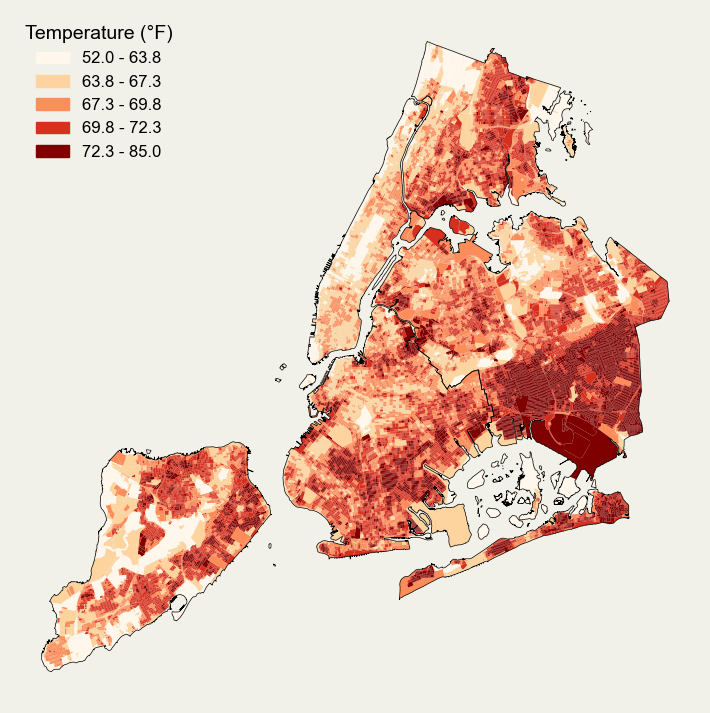

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as colors

boundary_gdf = gpd.read_file("../USGS_Raster/Borough.geojson")
boundary_gdf = boundary_gdf.to_crs(block_gdf.crs)

# Using NaturalBreak to classify
classifier = mapclassify.NaturalBreaks(block_gdf['temperature_F'], k=5)
block_gdf['bin'] = classifier.yb
bin_edges = [block_gdf['temperature_F'].min()] + list(classifier.bins)
# Legend's Label
labels = [f"{round(bin_edges[i], 1)} - {round(bin_edges[i+1], 1)}" for i in range(len(bin_edges)-1)]

# Setting Up the plt
plt.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor("#F1F0E9")
ax.set_facecolor("#F1F0E9")

# Draw the pics
block_gdf.plot(column='bin',cmap='OrRd',ax=ax,legend=False,edgecolor='none')
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
ax.axis('off')

# Adding the Legend
cmap = plt.cm.OrRd
norm = colors.BoundaryNorm(boundaries=bin_edges, ncolors=cmap.N)
handles = [
    mpatches.Patch(color=cmap(norm((bin_edges[i] + bin_edges[i+1]) / 2)), label=labels[i]) 
    for i in range(len(labels))]
ax.legend(handles=handles,title="Temperature (°F)",loc='upper left',title_fontsize=14,fontsize=12,frameon=False)

# Save the pics
pics_path = 'pics.png'
fig.savefig(pics_path, dpi=300, facecolor='#F1F0E9')
plt.show()

In [30]:
import requests
import csv
import pandas as pd
import geopandas as gpd
import os

bg = gpd.read_file("../USGS_Raster/BlockGroup_shp/tl_2021_36_bg.shp")
bg = bg[bg['COUNTYFP'].isin(['005', '047', '061', '081', '085'])]
bg.rename(columns={'GEOID':'geoid'},inplace=True)
bg = bg[['geoid','geometry']]

data_url_base = "https://api.census.gov/data/2023/acs/acs5?get="
pop_variable = "B01001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B19013_001E"
edu_variable = 'B15003_001E,B15003_022E,B15003_023E,B15003_024E,B15003_025E'
other_variable = 'B25046_001E'
variable = pop_variable + "," + edu_variable + ',' + other_variable
data_url = data_url_base + variable
data_url = data_url + '&for=block%20group:*&in=state:36&in=county:*&in=tract:*' + "&key=6787aadbdc0868ff9ba8e09b83cb3f4cf392b239"
print(data_url)
response = requests.get(data_url)
popdata = response.json()
df = pd.DataFrame(popdata)
df.columns = df.iloc[0]
df = df[1:]
    
df.rename(columns={'B01001_001E': 'Total Population',
                   'B02001_002E': 'White',
                   'B02001_003E': 'Black',
                   'B02001_004E': 'American Indian and Alaska Native',
                   'B02001_005E': 'Asian',
                   'B02001_006E': 'Native Hawaiian and Other Pacific Islander',
                   'B02001_007E': 'Some other',
                   'B15003_001E': 'Total Over 25',
                   'B15003_022E': 'Bachelor',
                   'B15003_023E': 'Master',
                   'B15003_024E': 'Professional',
                   'B15003_025E': 'Doctor',
                   'B19013_001E': 'Median Household Income', 
                   'B25046_001E': 'Total Vehicle',
                   }, inplace=True)
df['geoid'] = df['state'] + df['county'] + df['tract'] + df["block group"]
df['Over Bachelor'] = (df['Bachelor'].astype(int) + df['Master'].astype(int) + df['Professional'].astype(int) + df['Doctor'].astype(int))

df = df.drop(['state','county','tract', "block group",'Bachelor','Master','Professional','Doctor'], axis=1) 
bg = bg.merge(df, on='geoid',how='left')
# bg.head()
bg.to_file("../USGS_Raster/BlockGroup.geojson", driver="GeoJSON")

https://api.census.gov/data/2023/acs/acs5?get=B01001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B19013_001E,B15003_001E,B15003_022E,B15003_023E,B15003_024E,B15003_025E,B25046_001E&for=block%20group:*&in=state:36&in=county:*&in=tract:*&key=6787aadbdc0868ff9ba8e09b83cb3f4cf392b239


,geoid,geometry,Total Population,White,Black,American Indian and Alaska Native,Asian,Native Hawaiian and Other Pacific Islander,Some other,Median Household Income,Total Over 25,Total Vehicle,Over Bachelor
0,360470314013,"POLYGON ((-73.99968 40.58609, -73.99955 40.586...",896,549,35,0,311,0,1,79607,621,None,193
1,360471070031,"POLYGON ((-73.88221 40.6545, -73.88059 40.6552...",0,0,0,0,0,0,0,-666666666,0,-666666666,0
2,360471070021,"POLYGON ((-73.87835 40.63887, -73.8779 40.6398...",0,0,0,0,0,0,0,-666666666,0,-666666666,0
3,360471034021,"POLYGON ((-73.88636 40.63082, -73.88592 40.631...",0,0,0,0,0,0,0,-666666666,0,-666666666,0
4,360470018012,"POLYGON ((-74.00466 40.66095, -74.00246 40.659...",1564,750,750,10,43,11,0,-666666666,1396,-666666666,11


In [48]:
bg_gdf = gpd.read_file("../USGS_Raster/BlockGroup.geojson")
boundary_gdf = gpd.read_file("../USGS_Raster/Borough.geojson")
boundary_gdf = boundary_gdf.to_crs(bg_gdf.crs)
bg_gdf = gpd.clip(bg_gdf, boundary_gdf)

raster_path = "temperature_weighted.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

bg_gdf = bg_gdf.to_crs(raster_crs)
stats = zonal_stats(
    bg_gdf, 
    raster_path, 
    stats=["mean"], 
    nodata=np.nan
)

bg_gdf['temperature_DN'] = [item['mean'] for item in stats]
bg_gdf.dropna(subset=['temperature_DN'], inplace=True)
bg_gdf['temperature_K'] = block_gdf['temperature_DN'] * 0.00341802 + 149
bg_gdf['temperature_F'] = (block_gdf['temperature_K'] -273.15) * 9 / 5 + 32
bg_gdf.head()
# 可以保存成新的 geojson 或 shapefile
bg_gdf.to_file("blockgroup_with_temperature.geojson", driver="GeoJSON")

In [50]:
boundary_gdf = gpd.read_file("../USGS_Raster/Borough.geojson")
bg_gdf = gpd.read_file('blockgroup_with_temperature.geojson')
boundary_gdf = boundary_gdf.to_crs(bg_gdf.crs)

# bg_gdf = gpd.sjoin(bg_gdf, boundary_gdf, how='inner', predicate='within')

# Using NaturalBreak to classify
# bg_gdf.dropna(subset=['temperature_F'], inplace=True)
classifier = mapclassify.NaturalBreaks(bg_gdf['temperature_F'], k=5)
bg_gdf['bin'] = classifier.yb
bin_edges = [bg_gdf['temperature_F'].min()] + list(classifier.bins)
# Legend's Label
labels = [f"{round(bin_edges[i], 1)} - {round(bin_edges[i+1], 1)}" for i in range(len(bin_edges)-1)]

# Setting Up the plt
plt.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor("#F1F0E9")
ax.set_facecolor("#F1F0E9")

# Draw the pics
bg_gdf.plot(column='bin',cmap='OrRd',ax=ax,legend=False,edgecolor='none')
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
ax.axis('off')

# Adding the Legend
cmap = plt.cm.OrRd
norm = colors.BoundaryNorm(boundaries=bin_edges, ncolors=cmap.N)
handles = [
    mpatches.Patch(color=cmap(norm((bin_edges[i] + bin_edges[i+1]) / 2)), label=labels[i]) 
    for i in range(len(labels))]
ax.legend(handles=handles,title="Temperature (°F)",loc='upper left',title_fontsize=14,fontsize=12,frameon=False)

# Save the pics
pics_path = 'pics.png'
fig.savefig(pics_path, dpi=300, facecolor='#F1F0E9')
plt.show()

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values